# Exercise 3: Lasso Regression

Investigate how alpha affects coefficients, feature selection, and prediction error on the Boston Housing dataset.

## 1. Load the data

Read the included CSV. Following the original notebook, retain observations with `MEDV < 50`. The target remains in thousands of dollars without a log transformation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

data_path = Path("BostonHousing.csv")

data = pd.read_csv(data_path)
data.columns = data.columns.str.upper()
data = data.loc[data["MEDV"] < 50].copy()
print(f"Loaded {len(data)} rows from {data_path.name}")
data.head()

Loaded 490 rows from BostonHousing.csv


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 2. Select features and split the data

Use eight predictors and an 80/20 train–test split. A fixed random seed provides the same split for each alpha.

In [2]:
features = ["LSTAT", "INDUS", "NOX", "PTRATIO", "RM", "TAX", "DIS", "AGE"]
X = data[features]
y = data["MEDV"]

assert not X.isna().any().any(), "The input data contains missing values."
assert not y.isna().any(), "The target contains missing values."

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 392
Test rows: 98


## 3. Fit Lasso

Standardize the predictors and fit Lasso in a pipeline. Scaling is learned from training data only. Coefficients represent changes in MEDV per one training-standard-deviation increase in a predictor, holding other predictors fixed.

In [3]:
model = make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=10000))
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f"Test MSE: {mean_squared_error(y_test, predictions):.3f}")
print(f"Test R²: {r2_score(y_test, predictions):.3f}")
pd.Series(model.named_steps["lasso"].coef_, index=features, name="Weight")

Test MSE: 13.748
Test R²: 0.731


LSTAT     -2.942668
INDUS     -0.526981
NOX       -0.887699
PTRATIO   -1.726932
RM         2.591552
TAX       -0.801206
DIS       -1.502176
AGE       -0.429234
Name: Weight, dtype: float64

## 4. Compare alpha values

Record training and test MSE, test R², non-zero coefficient counts, and dropped features. Lower MSE indicates better prediction performance.

In [4]:
alphas = [0.01, 0.1, 1, 10, 100]
rows = []
weights = []

for alpha in alphas:
    lasso_model = make_pipeline(
        StandardScaler(), Lasso(alpha=alpha, max_iter=10000)
    )
    lasso_model.fit(X_train, y_train)
    train_predictions = lasso_model.predict(X_train)
    test_predictions = lasso_model.predict(X_test)
    coefficients = lasso_model.named_steps["lasso"].coef_
    dropped = [feature for feature, weight in zip(features, coefficients) if weight == 0]

    rows.append({
        "Alpha": alpha,
        "Train MSE": mean_squared_error(y_train, train_predictions),
        "Test MSE": mean_squared_error(y_test, test_predictions),
        "Test R²": r2_score(y_test, test_predictions),
        "Non-zero weights": np.count_nonzero(coefficients),
        "Dropped features": ", ".join(dropped) or "None",
    })
    weights.append(coefficients)

results = pd.DataFrame(rows).set_index("Alpha")
coefficient_table = pd.DataFrame(weights, index=alphas, columns=features)
coefficient_table.index.name = "Alpha"
with pd.option_context("display.max_colwidth", None):
    display(results.round(3))

,Train MSE,Test MSE,Test R²,Non-zero weights,Dropped features
Alpha,,,,,
0.01,15.746,13.531,0.735,8,None
0.10,15.877,13.748,0.731,8,None
1.00,18.949,16.874,0.670,5,"NOX, DIS, AGE"
10.00,63.628,54.945,-0.076,0,"LSTAT, INDUS, NOX, PTRATIO, RM, TAX, DIS, AGE"
100.00,63.628,54.945,-0.076,0,"LSTAT, INDUS, NOX, PTRATIO, RM, TAX, DIS, AGE"


### Coefficients

Zero coefficients indicate unused features. Displayed coefficients are rounded; feature counts use the original values.

In [5]:
coefficient_table.round(4)

,LSTAT,INDUS,NOX,PTRATIO,RM,TAX,DIS,AGE
Alpha,,,,,,,,
0.01,-2.9116,-0.6356,-1.1423,-1.7963,2.6179,-0.7871,-2.0390,-0.6660
0.10,-2.9427,-0.5270,-0.8877,-1.7269,2.5916,-0.8012,-1.5022,-0.4292
1.00,-2.8667,-0.0854,-0.0000,-1.1502,2.1997,-0.6548,0.0000,-0.0000
10.00,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000
100.00,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000


## 5. Regularization plots

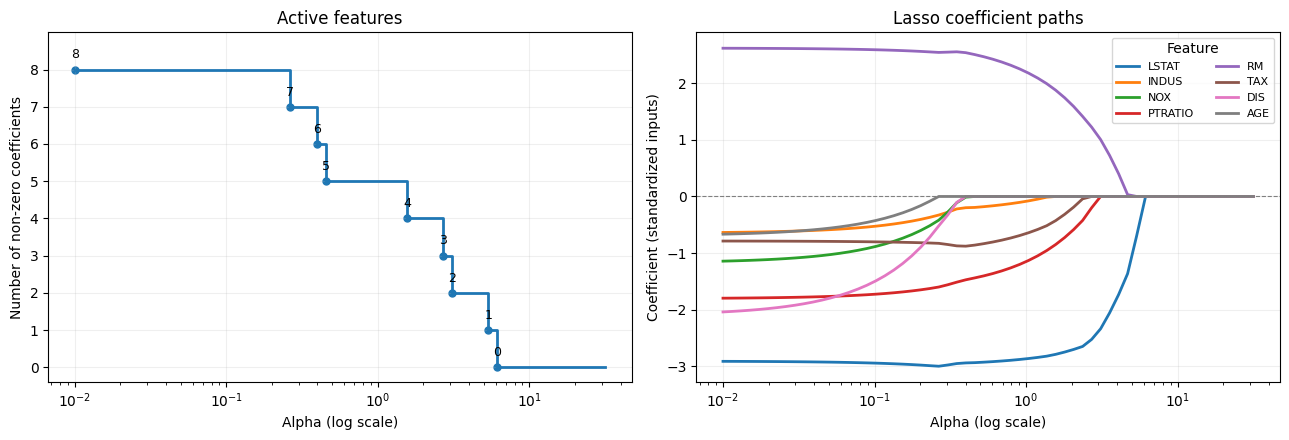

In [6]:
plot_alphas = np.logspace(-2, 1.5, 60)
plot_coefficients = []

for alpha in plot_alphas:
    path_model = make_pipeline(
        StandardScaler(), Lasso(alpha=alpha, max_iter=10000)
    )
    path_model.fit(X_train, y_train)
    plot_coefficients.append(path_model.named_steps["lasso"].coef_)

plot_coefficients = np.array(plot_coefficients)
nonzero_counts = np.count_nonzero(plot_coefficients, axis=1)

fig, (count_ax, path_ax) = plt.subplots(figsize=(13, 4.5), ncols=2)

count_ax.step(plot_alphas, nonzero_counts, where="post", linewidth=2)
label_indices = np.r_[0, np.flatnonzero(np.diff(nonzero_counts)) + 1]
count_ax.scatter(plot_alphas[label_indices], nonzero_counts[label_indices], s=25)
for index in label_indices:
    count_ax.annotate(
        str(nonzero_counts[index]),
        (plot_alphas[index], nonzero_counts[index]),
        xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9,
    )
count_ax.set_title("Active features")
count_ax.set_ylabel("Number of non-zero coefficients")
count_ax.set_yticks(range(len(features) + 1))
count_ax.set_ylim(-0.4, len(features) + 1)

for index, feature in enumerate(features):
    path_ax.plot(plot_alphas, plot_coefficients[:, index], label=feature, linewidth=2)
path_ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
path_ax.set_title("Lasso coefficient paths")
path_ax.set_ylabel("Coefficient (standardized inputs)")
path_ax.legend(title="Feature", fontsize=8, ncol=2)

for ax in (count_ax, path_ax):
    ax.set_xscale("log")
    ax.set_xlabel("Alpha (log scale)")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Selected features

In [7]:
for alpha, row in results.iterrows():
    print(f"Alpha {alpha:g}: {int(row['Non-zero weights'])} features used; dropped: {row['Dropped features']}")

if results.iloc[-1]["Non-zero weights"] == 0:
    print("\nAt the largest alpha, all feature weights are zero.")
    print("The model predicts the training target mean for every house (only the intercept remains).")

Alpha 0.01: 8 features used; dropped: None
Alpha 0.1: 8 features used; dropped: None
Alpha 1: 5 features used; dropped: NOX, DIS, AGE
Alpha 10: 0 features used; dropped: LSTAT, INDUS, NOX, PTRATIO, RM, TAX, DIS, AGE
Alpha 100: 0 features used; dropped: LSTAT, INDUS, NOX, PTRATIO, RM, TAX, DIS, AGE

At the largest alpha, all feature weights are zero.
The model predicts the training target mean for every house (only the intercept remains).


## Conclusion

At alpha 0.01 and 0.1, all eight predictors remain active. At alpha 1, NOX, DIS, and AGE receive zero coefficients, leaving five predictors. At alpha 10 and 100, all coefficients become zero: the model predicts the training target mean for every observation.

Alpha 0.01 has the lowest test MSE among the tested values on this split. Increasing regularization simplifies the model but worsens test error here. The largest values cause underfitting.

### Exercise questions

**Why does Lasso produce exact zeros while Ridge generally does not?**
- Lasso penalizes absolute coefficients (L1); its penalty has a corner at zero, allowing exact-zero solutions. Ridge penalizes squared coefficients (L2), generally shrinking them without eliminating them.

**Which method would suit 1,000 predictors with only 10 useful ones?** 
- Lasso is a suitable starting point for feature selection. It is not guaranteed to recover exactly those 10 predictors, especially with correlated inputs.

**Limitations:** Results describe one split of the filtered dataset. Zero coefficients do not establish that features are universally irrelevant. Selecting alpha for a final model should use cross-validation within the training set and reserve the test set for final evaluation.